# <span style="color:#2563EB"><strong>Validation of Medical Imaging AI</strong></span>
## Day 3 — Ranking Robustness  
### Worked practical handout

This handout contains the practical tasks, solution code, computed results, and concise interpretation notes for:

- **Practical 2.1:** Mean vs. median aggregation of case-wise DSC scores  
- **Practical 2.2:** Ranking robustness analysis with Rankings Reloaded

<div style="background-color:#EFF6FF; padding:14px; border-left:5px solid #2563EB; border-radius:8px">

<strong>Main learning objective</strong><br>
A leaderboard ranking is not only determined by model performance. It also depends on how case-level results are aggregated and how robust the resulting ranks are to uncertainty.

</div>

# <span style="color:#2563EB"><strong>Practical 2.1 — Mean vs. median aggregation</strong></span>

In this practical, we analyzed case-wise Dice Similarity Coefficient (**DSC**) values for 10 algorithms evaluated on 200 images. Each algorithm has one DSC score per image. Higher DSC is better.

The goal was to investigate whether rankings change when we aggregate case-wise DSC scores using the **mean** versus the **median**.

## <span style="color:#F59E0B"><strong>Solution code: Rankings</strong></span>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the practical dataset.
results = pd.read_csv("data_day3_practical_2_1.csv")

# Calculate rankings based on mean and median
summary = (
    results
    .groupby("algorithm")
    .agg(
        mean_dsc=("dsc", "mean"),
        median_dsc=("dsc", "median"),
    )
)

summary["rank_by_mean"] = (
    summary["mean_dsc"]
    .rank(ascending=False, method="min")
    .astype(int)
)

summary["rank_by_median"] = (
    summary["median_dsc"]
    .rank(ascending=False, method="min")
    .astype(int)
)

summary = summary.sort_values("rank_by_mean")
summary

,mean_dsc,median_dsc,rank_by_mean,rank_by_median
algorithm,,,,
A1,0.786652,0.64190,1,10
A2,0.763273,0.84060,2,2
A3,0.741209,0.82015,3,3
A5,0.729240,0.85740,4,1
A4,0.704082,0.79725,5,4
A10,0.692024,0.69380,6,9
A6,0.673017,0.77410,7,5
A9,0.668017,0.69620,8,8
A7,0.653382,0.76300,9,6


<div style="background-color:#FFF7ED; padding:12px; border-left:5px solid #F59E0B; border-radius:8px">

<strong>Key observation</strong><br>
A1 wins when algorithms are ranked by the mean DSC, but drops to rank 10 when algorithms are ranked by the median DSC.

</div>

## <span style="color:#F59E0B"><strong>Solution code: Visualization</strong></span>

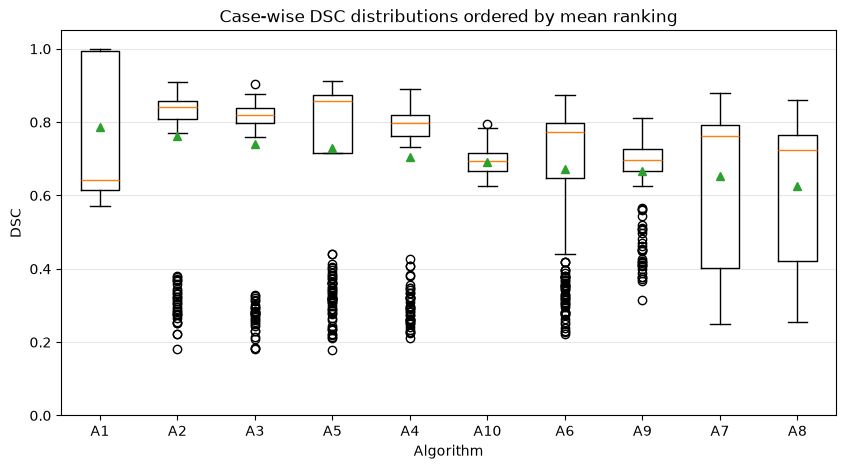

In [4]:
algorithm_order = summary.index.tolist()
plot_data = [results.loc[results["algorithm"] == alg, "dsc"] for alg in algorithm_order]

plt.figure(figsize=(10, 5))
plt.boxplot(plot_data, tick_labels=algorithm_order, showmeans=True)
plt.ylabel("DSC")
plt.xlabel("Algorithm")
plt.title("Case-wise DSC distributions ordered by mean ranking")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.show()

<div style="background-color:#ECFDF5; padding:12px; border-left:5px solid #059669; border-radius:8px">

<strong>Answer</strong><br>
The mean and median summarize different aspects of the case-wise performance distribution. The mean preserves the magnitude of all values, but can be strongly affected by extreme high or low scores. The median is more robust to outliers, but ignores how far values lie above or below the middle of the distribution. In this example, the ranking winner depends strongly on the aggregation operator.

</div>

# <span style="color:#2563EB"><strong>Practical 2.2 — Ranking robustness with Rankings Reloaded</strong></span>

In this practical, we used [Rankings Reloaded](https://www.rankings-reloaded.de/) to investigate ranking robustness of two different tasks.

The dataset contains two tasks:

- **c_ideal:** Algorithms are clearly separated. The data simulates uniform samples from [0.9, 1), [0.8, 0.9), [0.7, 0.8), [0.6, 0.7) and [0.5, 0.6) for algorithms A1, A2, ..., A5, respectively.
- **c_random:** Algorithms have strongly overlapping performance distributions. 250 random normal values with a mean of 1.5 and variance 1 were drawn and transformed by the logistic function to obtain a skewed distribution on [0, 1]. These were then assigned to algorithms to A1-A5, resulting in n = 50 test cases. Thus, there is no systematic difference between the algorithms, any difference can be attributed to chance alone.

Rankings Reloaded was used with a metric-based aggregation based on the mean. 1,000 bootstrap rankings were generated.

## <span style="color:#2563EB"><strong>Dots- and boxplots</strong></span>

**Question:** Based on the boxplots, what is the main difference between the two tasks? Which task is more likely to produce a robust ranking?

<div style="background-color:#ECFDF5; padding:12px; border-left:5px solid #059669; border-radius:8px">

<strong>Answer</strong><br>
In <strong>c_ideal</strong>, the algorithms are clearly separated. The metric score distributions show little overlap and the order of algorithms is visually obvious. In <strong>c_random</strong>, the distributions overlap strongly, so the apparent ranking is much less convincing.
    
<strong>c_ideal</strong> is more likely to produce a robust ranking because the algorithms are well separated across cases. In <strong>c_random</strong>, many algorithms perform similarly and their score distributions overlap, so small changes in the test sample can change the ranking.

</div>

## <span style="color:#2563EB"><strong>Podium plots</strong></span>

**Question:** What do the podium plots show?

<div style="background-color:#ECFDF5; padding:12px; border-left:5px solid #059669; border-radius:8px">

<strong>Answer</strong><br>
Podium plots provide insight into the distribution of case-wise ranks. The lower bar charts summarize how often each algorithm achieves rank 1, 2, 3, etc. The upper "spaghetti" plot allows inspection of individual test cases. Cases for which all algorithms perform poorly (or well) can be identified directly from the metric values, while strong line crossings indicate that algorithms frequently change their relative ordering from one case to another. In <strong>c_ideal</strong>, most algorithms occupy similar podium positions across cases, resulting in a stable ranking. In <strong>c_random</strong>, frequent rank changes and broader rank distributions suggest that the benchmark provides less consistent evidence for a clear ordering of algorithms.

</div>

## <span style="color:#2563EB"><strong>Bootstrap blob plots</strong></span>

**Question:** Which statement is best supported by the blob plots?

<div style="background-color:#F8FAFC; padding:12px; border-left:5px solid #64748B; border-radius:8px">

<strong>Correct statement</strong><br>
Algorithms in <strong>c_random</strong> frequently change rank across bootstrap samples.

</div>
<div><br></div>

<div style="background-color:#ECFDF5; padding:12px; border-left:5px solid #059669; border-radius:8px">

<strong>Interpretation</strong><br>
Blob plots summarize the rankings obtained across bootstrap resamplings of the test set. They therefore show how sensitive the ranking is to small changes in the sampled cases. In <strong>c_ideal</strong>, each algorithm is concentrated around a single rank, indicating that the ranking remains largely unchanged across bootstrap samples and is therefore robust. In <strong>c_random</strong>, the same algorithm can appear at several ranks across bootstrap samples. This indicates that small changes in the composition of the test set can lead to different rankings, suggesting substantial ranking uncertainty and limited robustness.
</div>

## <span style="color:#2563EB"><strong>Kendall's τ violin plots</strong></span>

**Question:** What can we conclude from the violin plots?

<div style="background-color:#ECFDF5; padding:12px; border-left:5px solid #059669; border-radius:8px">

<strong>Answer</strong><br>
The violin plots summarize how similar the bootstrap rankings are to the ranking obtained from the full dataset. A Kendall's τ close to 1 indicates that the bootstrap rankings are highly consistent with the original ranking. In <strong>c_ideal</strong>, Kendall's τ is close to 1, indicating a reproducible ranking. In <strong>c_random</strong>, Kendall's τ is lower and more variable, indicating substantially weaker ranking robustness.

</div>